<a href="https://colab.research.google.com/github/Fjmoya-uba/Taller-Procesamiento-Se-ales/blob/main/TPs/TPS_02-Francisco-Javier-Moya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°2 de TPS: Regresión Polinómica

## Ítem A

### Punto 1


Preparación del entorno de programación.

In [1]:
# Se importan las librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn import set_config

Carga de la base de datos y comprobación de los mismos.

In [2]:
# Se carga la base de datos
df = sns.load_dataset('healthexp')
df

,Year,Country,Spending_USD,Life_Expectancy
0,1970,Germany,252.311,70.6
1,1970,France,192.143,72.2
2,1970,Great Britain,123.993,71.9
3,1970,Japan,150.437,72.0
4,1970,USA,326.961,70.9
...,...,...,...,...
269,2020,Germany,6938.983,81.1
270,2020,France,5468.418,82.3
271,2020,Great Britain,5018.700,80.4
272,2020,Japan,4665.641,84.7


### Punto 2

A partir de estos datos extraídos, se analiza la relación entre el gasto público en salud per cápita y la esperanza de vida mediante un gráfico de dispersión. Cada punto representa un país en un determinado año, y se utiliza un color distinto para identificar a cada uno.

El objetivo es observar posibles patrones o correlaciones entre ambas variables, y comparar cómo se comportan los distintos países.

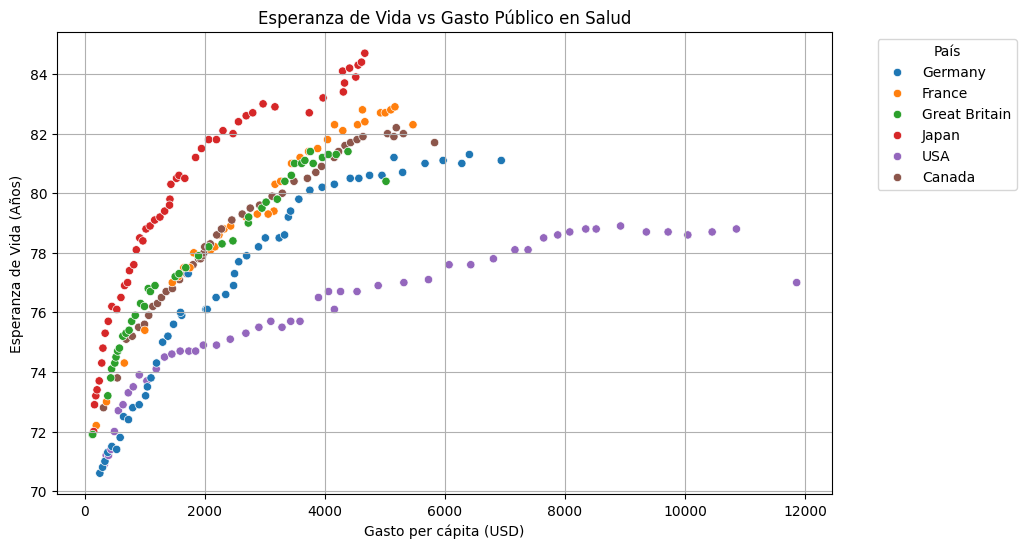

In [3]:
# Se grafica la relación entre esperanza de vida y gasto público
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Spending_USD', y='Life_Expectancy', hue='Country')
plt.title('Esperanza de Vida vs Gasto Público en Salud')
plt.xlabel('Gasto per cápita (USD)')
plt.ylabel('Esperanza de Vida (Años)')
plt.grid(True)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


A partir del gráfico se observa una relación creciente entre el gasto público en salud per cápita y la expectativa de vida. En términos generales, mayores niveles de gasto se asocian con mayores valores de longevidad.

Sin embargo, esta relación no es lineal. Para niveles bajos e intermedios de gasto, los incrementos generan mejoras relativamente significativas en la expectativa de vida. En cambio, a partir de aproximadamente 2008, varias curvas comienzan a aplanarse. Se observa que aumentos adicionales en el gasto se traducen en mejoras cada vez menores.

En los últimos años de la serie también se aprecia que, salvo en Japón, varios países incrementan su gasto mientras que la expectativa de vida se estanca o incluso disminuye levemente. Este comportamiento, particularmente visible en el último año de cada país, podría explicarse por el impacto de la pandemia de COVID-19, que habría elevado el gasto sanitario mientras aumentaba la mortalidad.

Por último, se evidencian diferencias entre países para niveles similares de gasto. En particular, Estados Unidos presenta niveles considerablemente más altos sin alcanzar las mayores expectativas de vida, mientras que Japón logra mejores resultados con menor gasto, lo que indica que la longevidad depende también de factores estructurales más allá de la inversión en salud.

### Punto 3

Los datos se dividieron en conjuntos de entrenamiento, validación y testeo utilizando un criterio temporal. A lo largo de este trabajo práctico, se entrenará al modelo con observaciones anteriores a 2008, se lo validará con los datos entre 2008 y 2015, y se evaluará su desempeño final con datos posteriores a 2015. Esta partición permite simular un escenario más realista, en el cual el modelo aprende a partir del pasado y se evalúa sobre años futuros.

In [4]:
# Se definen conjuntos de entrenamiento, validación y testeo
train_df = df[df['Year'] < 2008]
val_df = df[(df['Year'] >= 2008) & (df['Year'] <= 2015)]
test_df = df[df['Year'] > 2015]

# Se verifica la cantidad de registros en cada conjunto
print(f"Registros - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Registros - Train: 196, Val: 48, Test: 30


## Ítem B

En este apartado se preparan los datos antes de entrenar el modelo. La idea es transformar las variables originales a una forma que el algoritmo pueda usar correctamente. En particular, se trabaja por un lado con la variable categórica `Country`, que debe convertirse en variables numéricas, y por otro lado con la variable de gasto, sobre la cual se busca construir una representación que permita capturar relaciones no lineales.

### Punto 1

La variable `Country` indica a qué país pertenece cada dato, pero como es una variable categórica, no se la puede usar directamente como un número. Por ejemplo, no tendría sentido decir que Japón vale 1, USA vale 2 y Alemania vale 3, porque eso haría parecer que hay un orden entre países, cuando en realidad no lo hay.

Para resolver esto se usa `OneHotEncoder`, que transforma cada país en una variable binaria. Es decir, para cada país se crea una columna que vale 1 si el dato pertenece a ese país y 0 si no pertenece.

Si hay \(K\) países distintos, entonces se generan \(K\) variables indicadoras. De esta forma, el modelo puede distinguir de qué país viene cada observación sin inventar relaciones de orden que no existen.

En este trabajo, esta transformación es útil porque en el gráfico se ve que, para niveles parecidos de gasto público en salud, no todos los países tienen exactamente la misma esperanza de vida. Entonces, codificar el país de esta manera permite que el modelo tenga en cuenta esas diferencias.

In [5]:
# Se configura el codificador OneHot
encoder = OneHotEncoder(sparse_output=False)

# Se muestra ejemplo de transformación
paises_encoded = encoder.fit_transform(train_df[['Country']])
nombres_columnas = encoder.get_feature_names_out(['Country'])

print("Nuevas columnas creadas:", nombres_columnas)
print("Ejemplo de las primeras filas:\n", paises_encoded[:5])

Nuevas columnas creadas: ['Country_Canada' 'Country_France' 'Country_Germany'
 'Country_Great Britain' 'Country_Japan' 'Country_USA']
Ejemplo de las primeras filas:
 [[0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]


### Punto 2

Sobre la variable `Spending_USD` se aplica una transformación polinómica de grado 3, generando las variables ($x$), ($x^2$) y ($x^3$). Esta elección busca darle al modelo la posibilidad de ajustarse a una relación curva entre el gasto público en salud y la esperanza de vida.

Esto resulta razonable a partir del análisis gráfico, donde se observa que la relación entre ambas variables no sigue una recta: para ciertos rangos de gasto la esperanza de vida crece con mayor intensidad, mientras que en otros la tendencia se va aplanando. En consecuencia, trabajar solamente con la variable original sería demasiado restrictivo, mientras que incorporar términos de segundo y tercer grado permite representar mejor esa forma.

De esta manera, el grado 3 aparece como una elección intermedia: suficientemente flexible para capturar la curvatura observada, pero sin introducir una complejidad demasiado alta. Además, esta elección coincide con lo indicado en el enunciado del trabajo práctico.

In [6]:
# Se configura el generador de características polinómicas de grado 3
poly = PolynomialFeatures(degree=3, include_bias=False)

# Se muestra ejemplo de transformación
gasto_poly = poly.fit_transform(train_df[['Spending_USD']])
print("Primeras filas con [x, x^2, x^3]:\n", gasto_poly[:5])

Primeras filas con [x, x^2, x^3]:
 [[2.52311000e+02 6.36608407e+04 1.60623304e+07]
 [1.92143000e+02 3.69189324e+04 7.09371444e+06]
 [1.23993000e+02 1.53742640e+04 1.90630112e+06]
 [1.50437000e+02 2.26312910e+04 3.40458352e+06]
 [3.26961000e+02 1.06903496e+05 3.49532738e+07]]


### Punto 3

En este paso se juntan las transformaciones hechas sobre cada variable de entrada. Por un lado, la variable `Country` se convierte en \(K\) columnas binarias, donde \(K\) es la cantidad de países distintos. Por otro lado, la variable `Spending_USD` se reemplaza por tres columnas: \($x$\), \($x^2$\) y \($x^3$\).

De esta manera, cada observación deja de estar representada por solo dos datos originales y pasa a describirse mediante un vector de \(K+3\) componentes. Las primeras \(K\) posiciones indican el país, y las tres restantes contienen la información del gasto y sus potencias.

Luego, sobre esa nueva matriz se aplica una normalización, restando la media y dividiendo por el desvío estándar. Esto no cambia el significado de las variables, sino que las lleva a una escala comparable. La idea es evitar que algunas columnas dominen a las demás solo por tener valores numéricamente más grandes.

In [7]:
# Se combinan las transformaciones de tabla y polinomio
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Country']),
        ('poly', PolynomialFeatures(degree=3, include_bias=False), ['Spending_USD'])
    ]
)

# Se aplica la transformación y normalización
X_train_raw = train_df[['Country', 'Spending_USD']]
X_train_combined = preprocessor.fit_transform(X_train_raw)

scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_combined)

print("Forma final de la matriz de entrenamiento:", X_train_final.shape)
print("Los datos ahora están normalizados (media ~0 y varianza ~1)")

Forma final de la matriz de entrenamiento: (196, 9)
Los datos ahora están normalizados (media ~0 y varianza ~1)


## Ítem C

En este punto se arma el modelo completo. Es decir, se toman las variables originales (`Country` y `Spending_USD`), se les aplican las transformaciones del ítem B y, con eso, se entrena un modelo para predecir la esperanza de vida.

La idea es simple: el país se usa para distinguir diferencias entre países, y el gasto público en salud se usa en forma polinómica para que el modelo no quede limitado a una recta. Así, el sistema puede ajustarse mejor a la forma que muestran los datos.

Una vez armado el modelo, se lo entrena con el conjunto de entrenamiento, se evalúa qué tan bien funciona sobre entrenamiento y validación, y después se grafica el ajuste obtenido para cada país.

### Puntos 1 y 3


En este punto se arma el modelo completo como una secuencia de pasos. Primero se aplica el preprocesamiento de las variables, después la normalización y al final la regresión.

También se muestra el diagrama del sistema, para ver de manera más clara cómo está organizado el modelo.

In [8]:
# Se crea el pipeline con preprocesamiento, normalización y regresión
model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Se muestra el diagrama del sistema
set_config(display="diagram")
model_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['Country']),
                                                 ('poly',
                                                  PolynomialFeatures(degree=3,
                                                                     include_bias=False),
                                                  ['Spending_USD'])])),
                ('scaler', StandardScaler()),
                ('regressor', LinearRegression())])

### Punto 2


In [9]:
X_train = train_df[['Country', 'Spending_USD']]
y_train = train_df['Life_Expectancy']

X_val = val_df[['Country', 'Spending_USD']]
y_val = val_df['Life_Expectancy']

X_test = test_df[['Country', 'Spending_USD']]
y_test = test_df['Life_Expectancy']

print("Variables X e y definidas correctamente.")

Variables X e y definidas correctamente.


In [10]:
# Se calcula la cantidad de parámetros del modelo
preprocessor.fit(X_train)
n_paises = len(preprocessor.transformers_[0][1].get_feature_names_out())
n_poly = 3

print(f"Parámetros por países (OneHot): {n_paises}")
print(f"Parámetros por gasto (Polinomio): {n_poly}")
print(f"Total de coeficientes (w): {n_paises + n_poly}")
print(f"Intersección (bias/b): 1")
print(f"Total de parámetros del modelo: {n_paises + n_poly + 1}")

Parámetros por países (OneHot): 6
Parámetros por gasto (Polinomio): 3
Total de coeficientes (w): 9
Intersección (bias/b): 1
Total de parámetros del modelo: 10


Luego del preprocesamiento, cada dato deja de estar representado solo por `Country` y `Spending_USD`, y pasa a describirse mediante 9 variables, como se observa en la celda de código arriba. De ellas, 6 corresponden a la codificación del país y 3 a la transformación polinómica del gasto: \($x$\), \($x^2$\) y \($x^3$\).

La cantidad de parámetros del modelo sale directamente de las variables que aparecen después del preprocesamiento. En este caso, el número 6 aparece porque en el conjunto de entrenamiento hay 6 países distintos. Como la variable `Country` se codifica con one-hot, se genera una columna por cada país. Por eso aparecen 6 variables asociadas al país.

El número 3 aparece porque sobre la variable `Spending_USD` se aplica una transformación polinómica de grado 3. Eso significa que, en lugar de usar solo la variable original, el modelo trabaja con tres columnas. Por eso hay 3 variables asociadas al gasto.

Por último, aparece el número 1 porque la regresión lineal incluye un término independiente, también llamado intercepto o bias. Ese término sirve como valor de base del modelo, es decir, un punto de partida a partir del cual después se suman los aportes de las demás variables.

Entonces, el total se entiende como:

$
6 \text{ (países)} + 3 \text{ (términos del polinomio)} + 1 \text{ (bias)} = 10
$

En otras palabras, el modelo tiene un parámetro por cada columna de entrada generada, más un parámetro extra que actúa como término base.



Con estas variables, el modelo construye la salida estimada \($\hat y$\) como una suma de aportes: un término independiente, más un peso para cada país, más un peso para cada uno de los términos del polinomio. En forma esquemática:

$
\hat y = b + w_1c_1 + w_2c_2 + \dots + w_6c_6 + w_7x + w_8x^2 + w_9x^3
$

Así, aunque el modelo se ajusta como una combinación lineal de variables, puede representar una relación polinómica entre el gasto público en salud y la esperanza de vida.

### Puntos 4 y 5

En este paso se entrena el modelo usando el conjunto de entrenamiento. Es decir, a partir de los datos anteriores a 2008, el sistema ajusta sus parámetros para poder predecir la esperanza de vida.

Una vez entrenado, se generan predicciones tanto sobre el conjunto de entrenamiento como sobre el conjunto de validación (los datos entre 2008 y 2015). Luego, se calcula el error cuadrático medio (MSE) en ambos casos, con el objetivo de comparar qué tan bien ajusta el modelo los datos con los que aprendió y qué tan bien se comporta sobre datos no vistos durante el entrenamiento.

In [11]:
# Se entrena el modelo
model_pipeline.fit(X_train, y_train)

# Se calcula el error cuadrático medio en entrenamiento y validación
train_preds = model_pipeline.predict(X_train)
val_preds = model_pipeline.predict(X_val)

mse_train = mean_squared_error(y_train, train_preds)
mse_val = mean_squared_error(y_val, val_preds)

print(f"MSE Entrenamiento: {mse_train:.4f}")
print(f"MSE Validación: {mse_val:.4f}")

MSE Entrenamiento: 0.4265
MSE Validación: 5.3687


Los resultados muestran que el error sobre entrenamiento es mucho menor que el error sobre validación:

$
MSE_{train} = 0.4265
\qquad\qquad
MSE_{val} = 5.3687
$

Esto indica que el modelo logra ajustarse bien a los datos con los que fue entrenado, pero pierde precisión cuando se lo evalúa sobre datos más recientes.

Una posible explicación es que la relación entre gasto público en salud y esperanza de vida no se mantiene igual a lo largo de todo el período. En particular, a partir de 2008 varias trayectorias comienzan a aplanarse (como se había comentado en el punto 3 del ítem A), por lo que un modelo entrenado con años anteriores puede no representar tan bien ese comportamiento.

En otras palabras, el modelo aprende bien la tendencia del conjunto de entrenamiento, pero generaliza peor sobre el conjunto de validación.

### Punto 6

En este paso se grafica la regresión aprendida por el modelo para cada país. Para eso, se generan distintos valores de gasto público en salud dentro del rango de los datos y, para cada país, se calcula la esperanza de vida predicha por el modelo.

Luego, esas curvas se superponen con los datos originales. Esto permite comparar visualmente el ajuste del modelo y ver si las predicciones siguen una forma razonable para cada país.

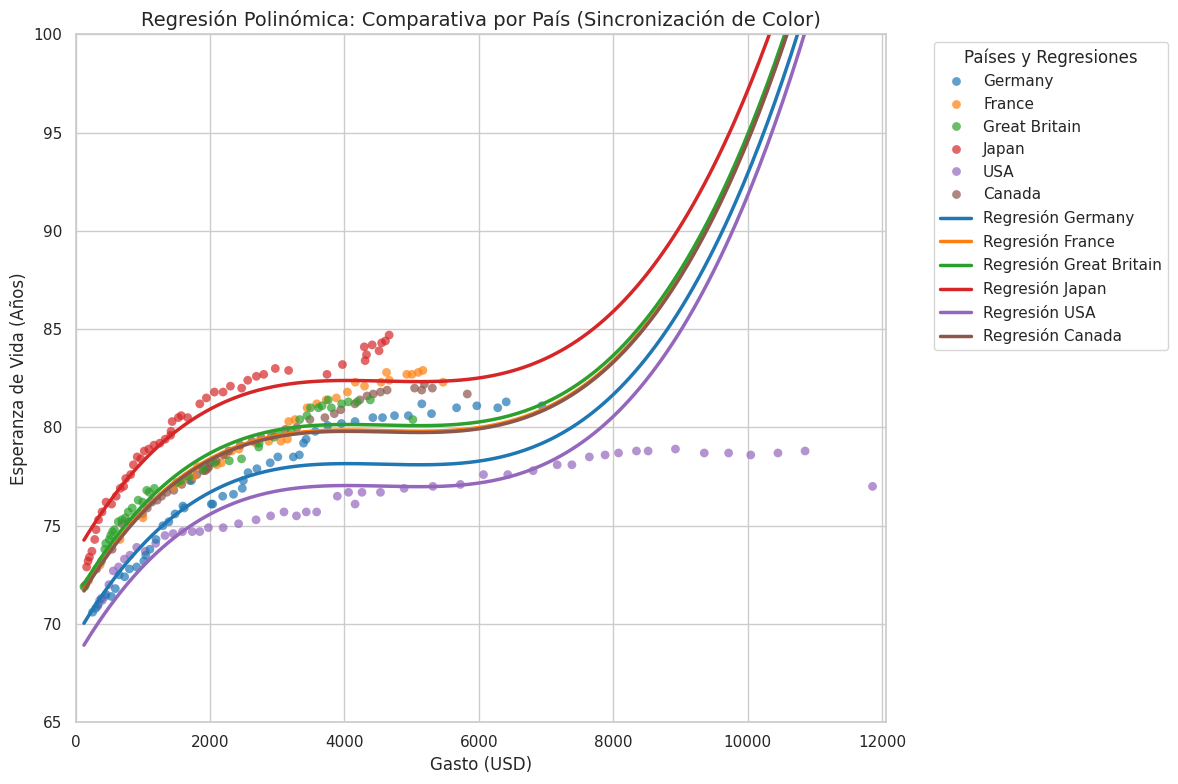

In [12]:
# Se configura el estilo y paleta de colores
sns.set_theme(style="whitegrid")
palette = sns.color_palette("tab10", n_colors=len(df['Country'].unique()))

plt.figure(figsize=(12, 8))

# Se grafican los datos reales
sns.scatterplot(
    data=df,
    x='Spending_USD',
    y='Life_Expectancy',
    hue='Country',
    palette=palette,
    s=40,
    alpha=0.7,
    edgecolor='none'
)

# Se generan las predicciones
gasto_max = df['Spending_USD'].max()
gasto_range = np.linspace(df['Spending_USD'].min(), gasto_max, 300)
paises = df['Country'].unique()

# Se trazan las curvas de regresión por país
for i, pais in enumerate(paises):
    X_plot = pd.DataFrame({'Country': [pais] * 300, 'Spending_USD': gasto_range})
    y_plot = model_pipeline.predict(X_plot)

    plt.plot(
        gasto_range,
        y_plot,
        color=palette[i],
        linewidth=2.5,
        label=f'Regresión {pais}'
    )

# Se ajusta la visualización
plt.ylim(65, 100)
plt.xlim(0, gasto_max + 200)

plt.title('Regresión Polinómica: Comparativa por País (Sincronización de Color)', fontsize=14)
plt.xlabel('Gasto (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)
plt.legend(title='Países y Regresiones', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Se observa que, en general, el modelo logra seguir la tendencia creciente de la esperanza de vida para valores bajos e intermedios de gasto (son los datos con los que el algoritmo fue entrenado). Por otro lado, como era esperado, las curvas generadas por el modelo, son polinomios de grado 3.

Sin embargo, el gráfico también deja ver una limitación fuerte del modelo. Para valores altos de gasto, varias curvas se disparan hacia arriba y llegan a predecir esperanzas de vida superiores a 100 años. Eso ya marca que el ajuste, en esa zona, dejó de ser realista. Los datos reales no muestran algo parecido a ese crecimiento, sino más bien un estancamiento.

La razón más probable es que el modelo está extrapolando (busca predecir en una zona donde casi no hay datos que lo guíen) con un polinomio de grado 3 en una región donde tiene poca información real. Mientras hay datos cerca, la curva todavía sigue una forma razonable. Pero cuando se aleja de esa zona, el polinomio empieza a crecer por la forma que tiene, no porque los datos indiquen que eso deba ocurrir. Es decir, la curva empieza a obedecer más a la matemática del modelo que al comportamiento real del fenómeno.

Visto así, el gráfico ayuda a entender mejor los errores obtenidos antes. El modelo ajusta bastante bien el conjunto de entrenamiento, pero al pasar a regiones más nuevas o más extremas pierde confiabilidad. Por eso no alcanza con que el error en entrenamiento sea bajo: también hace falta mirar si la forma de la regresión tiene sentido cuando se compara con los datos reales.

El desarrollo de este ítem muestra que no alcanza con entrenar un modelo y observar que funciona bien sobre los datos de entrenamiento. También es necesario evaluarlo sobre un conjunto de validación, ya que eso permite ver si realmente generaliza bien o si aparecen problemas que no se notaban al entrenarlo.

En este caso, si bien el modelo logra un error bajo sobre los datos de entrenamiento, al pasar al conjunto de validación el error aumenta de forma considerable. Además, al observar las curvas obtenidas, se ve que para ciertos rangos de gasto las predicciones dejan de resultar razonables. Esto indica que el modelo todavía no está capturando del todo bien el comportamiento de los datos.

Por lo tanto, el conjunto de validación cumple un rol importante: detectar si el modelo cumple con lo que se busca de él o necesita ser ajustado. En este trabajo, justamente permitió ver que el sistema todavía puede mejorarse, lo que da lugar a continuar ese análisis en el siguiente ítem.

## Ítem D

En este punto se intentará mejorar el modelo anterior usando regularización. La idea es seguir trabajando con el mismo modelo, pero agregando un control para que no ajuste de forma tan extrema.

Para eso se usa Ridge y se prueban distintos valores de ($\lambda$). Luego se compara el error en entrenamiento y validación para elegir la opción que mejor generaliza.

### ¿Qué es Ridge?

En la regresión lineal común, el modelo busca ajustar los datos minimizando el error cuadrático entre los valores reales ($y_i$) y los valores predichos \($\hat y_i$\). Ese error se escribe como:

$$
\sum_{i=1}^{N} (y_i - \hat y_i)^2
$$


Esto significa que el modelo busca que sus predicciones se parezcan lo más posible a los datos observados, penalizando con mayor fuerza los errores grandes. Al mismo tiempo, esta función define una superficie de costo (que puede pensarse como un “valle”) y el entrenamiento consiste en encontrar el punto donde ese costo es mínimo, de manera de obtener la mejor predicción posible.

Sin embargo, ajustar muy bien los datos de entrenamiento no siempre significa que el modelo vaya a funcionar bien sobre datos nuevos. En algunos casos, para lograr un ajuste muy fino, el modelo termina usando coeficientes demasiado grandes, lo que puede volverlo más inestable o exagerado al predecir fuera de la zona donde hay suficientes datos.

Para evitar eso, se usa Ridge, que modifica la función de costo agregando una penalización sobre el tamaño de los coeficientes. En este caso, el modelo pasa a minimizar:

$$
\sum_{i=1}^{N} (y_i - \hat y_i)^2 \;+\; \lambda \sum_{j=1}^{p} w_j^2
$$

Esta expresión tiene dos partes:

- La primera mide qué tan bien ajusta el modelo los datos.
- La segunda penaliza que los coeficientes \($w_j$\) tomen valores demasiado grandes.

El parámetro $\lambda$ controla cuánto pesa esa penalización.

- Si $\lambda$ es muy pequeño, el modelo se parece mucho a una regresión lineal común.
- Si $\lambda$ aumenta, los coeficientes son castigados con más fuerza y el modelo se vuelve más controlado.

La idea de Ridge, entonces, es encontrar un equilibrio entre dos cosas: ajustar bien los datos y evitar coeficientes excesivamente grandes.

En este trabajo, esto resulta útil porque en el ítem anterior se observó que el modelo ajustaba bien el conjunto de entrenamiento, pero no mantenía el mismo desempeño sobre validación. Además, las curvas obtenidas para valores altos de gasto crecían demasiado. En ese contexto, Ridge se usa como una forma de regularizar el modelo y hacerlo menos extremo.

### Puntos 1 y 2

En este paso se entrena el modelo Ridge para distintos valores del parámetro \($\lambda$\), con el objetivo de ver cómo cambia el ajuste del modelo al modificar la intensidad de la regularización.

Para cada valor de \($\lambda$\), se calcula el error cuadrático medio (MSE) tanto sobre el conjunto de entrenamiento como sobre el conjunto de validación. Luego, estos errores se graficarán para comparar el comportamiento del modelo y analizar qué nivel de regularización resulta más conveniente.

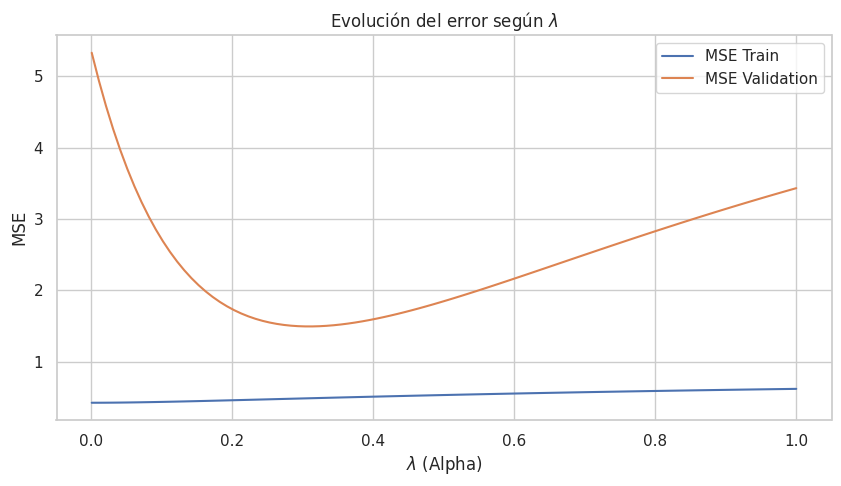

In [13]:
# Se prueban diferentes valores de lambda
lambdas = np.linspace(0.001, 1, 100)
train_errors = []
val_errors = []

for l in lambdas:
    # Se crea el pipeline con Ridge
    ridge_model = Pipeline([
        ('prep', preprocessor),
        ('scaler', StandardScaler()),
        ('regressor', Ridge(alpha=l))
    ])

    ridge_model.fit(X_train, y_train)

    # Se calcula el error para cada valor de lambda
    train_errors.append(mean_squared_error(y_train, ridge_model.predict(X_train)))
    val_errors.append(mean_squared_error(y_val, ridge_model.predict(X_val)))

# Se grafica la evolución del error
plt.figure(figsize=(10, 5))
plt.plot(lambdas, train_errors, label='MSE Train')
plt.plot(lambdas, val_errors, label='MSE Validation')
plt.title(r'Evolución del error según $\lambda$')
plt.xlabel(r'$\lambda$ (Alpha)')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

La idea de mirar ambas curvas al mismo tiempo es entender cómo afecta la regularización al modelo.

La curva de entrenamiento crece de forma muy suave cuando aumenta $\lambda$. Esto indica que, en el rango analizado, la regularización no perjudica demasiado el ajuste sobre los datos de entrenamiento. En otras palabras, aunque Ridge le quita algo de libertad al modelo, el MSE de entrenamiento empeora solo levemente.

Esto sugiere que el modelo original ya lograba un ajuste bastante bueno sobre el conjunto de entrenamiento, y que introducir la penalización no rompe ese comportamiento. Por eso, en este caso, el costo que se paga en entrenamiento al aumentar $\lambda$ es relativamente bajo.

La curva de validación es la más importante para la selección del modelo, ya que representa el error sobre datos que no fueron utilizados durante el entrenamiento. En este punto, el objetivo no es minimizar el error de entrenamiento, sino encontrar el valor de $\lambda$ que haga mínimo el error de validación, es decir:

$$
\lambda^\star = \arg\min_{\lambda} MSE_{val}(\lambda)
$$

A partir del gráfico se observa que, para valores muy pequeños de $\lambda$, el error de validación es elevado. Luego, al aumentar la regularización, dicho error disminuye de manera marcada hasta alcanzar un mínimo para un valor intermedio del mismo. Si la regularización sigue aumentando, el error vuelve a crecer, lo que indica que el modelo comienza a quedar excesivamente restringido.

Por lo tanto, el gráfico muestra que existe un compromiso entre un modelo con poca regularización, que no generaliza bien, y uno con regularización excesiva, que pierde capacidad de ajuste. En este caso, el mínimo de la curva de validación se ubica aproximadamente alrededor de $\lambda \approx 0.3$, por lo que esa zona aparece como la más conveniente para la selección del modelo.

### Puntos 3 y 4

Una vez calculado el error de validación para distintos valores de $\lambda$, se selecciona aquel que minimiza dicho error. Es decir, se elige el valor de regularización que mostró el mejor desempeño sobre el conjunto de validación.

Luego, con este valor, se construye el modelo final y se evalúa su desempeño sobre el conjunto de testeo (los datos del 2015 en adelante). Este paso permite medir cómo funciona la versión elegida del modelo sobre datos no utilizados ni en el entrenamiento ni en la selección del hiperparámetro.

In [14]:
# Se selecciona el lambda óptimo
idx_optimo = np.argmin(val_errors)
best_lambda = lambdas[idx_optimo]
print(f"El lambda óptimo es: {best_lambda:.4f}")

# Se entrena el modelo final con el lambda óptimo
final_ridge = Pipeline([
    ('prep', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_lambda))
])
final_ridge.fit(X_train, y_train)

# Se evalúa el modelo en el conjunto de testeo
mse_test_ridge = mean_squared_error(y_test, final_ridge.predict(X_test))
print(f"MSE de Testeo con Ridge: {mse_test_ridge:.4f}")

El lambda óptimo es: 0.3138
MSE de Testeo con Ridge: 5.2837


El valor óptimo encontrado fue:

$$
\lambda^\star = 0.3138
$$

y el error obtenido sobre el conjunto de testeo fue:

$$
MSE_{test} = 5.2837
$$

A primera vista, este resultado no muestra una mejora numérica importante respecto de lo que ya se venía observando en el modelo anterior. El error sigue estando en el mismo orden, por lo que no puede decirse que la regularización haya resuelto de manera significativa las limitaciones del ajuste. Además, esta comparación tampoco es completamente directa, ya que el error previo fue medido sobre validación, mientras que aquí se está evaluando sobre testeo. Es decir, no se trata exactamente del mismo conjunto de datos.

De todos modos, esto también era esperable. A partir del análisis gráfico realizado en el ítem anterior, ya se había observado que los datos previos a 2008 presentan una tendencia distinta de la que aparece luego en validación y testeo, donde varias trayectorias comienzan a aplanarse. En ese contexto, Ridge puede ayudar a controlar el tamaño de los coeficientes y a volver más estable el modelo, pero no puede compensar por sí solo un cambio en la dinámica de los datos ni reemplazar información que el modelo no vio durante el entrenamiento.

Desde un punto de vista práctico, incluso puede considerarse que el uso de Ridge resulta poco conveniente en este caso. Para aplicar la regularización fue necesario entrenar múltiples modelos, explorar distintos valores de $\lambda$ y aumentar el costo computacional del procedimiento. Sin embargo, la mejora obtenida en el error final fue muy pequeña. Por lo tanto, complejizar el modelo solo se justifica si esa complejidad adicional se traduce en una mejora significativa, cosa que en este caso no parece ocurrir.

Este resultado sugiere que el problema no pasa únicamente por la falta de regularización. También influyen la escasez de variables explicativas y la diferencia de comportamiento entre los datos de entrenamiento y los datos posteriores. En ese sentido, una posible mejora sería reentrenar el modelo final utilizando conjuntamente los datos de entrenamiento y validación una vez seleccionado $\lambda$, dejando el conjunto de testeo exclusivamente para la evaluación final. Esto permitiría que el modelo incorpore parte de la dinámica más reciente de los datos, aunque sin garantizar por ello una mejora drástica.

### Punto 5

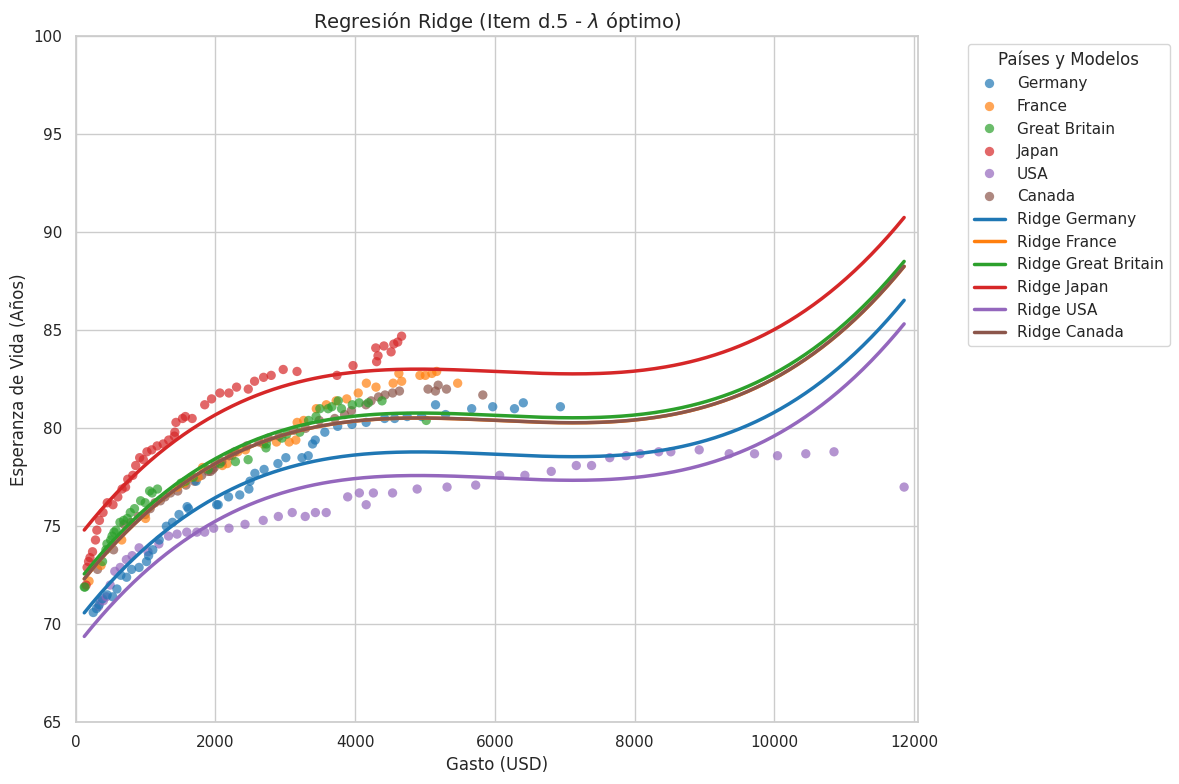

In [15]:
# Se configura el estilo y paleta de colores
sns.set_theme(style="whitegrid")
paises = df['Country'].unique()
palette = sns.color_palette("tab10", n_colors=len(paises))

plt.figure(figsize=(12, 8))

# Se grafican los datos reales
sns.scatterplot(
    data=df,
    x='Spending_USD',
    y='Life_Expectancy',
    hue='Country',
    palette=palette,
    s=45,
    alpha=0.7,
    edgecolor='none'
)

# Se generan las curvas de regresión Ridge
gasto_max = df['Spending_USD'].max()
gasto_range = np.linspace(df['Spending_USD'].min(), gasto_max, 300)

for i, pais in enumerate(paises):
    X_plot = pd.DataFrame({'Country': [pais] * 300, 'Spending_USD': gasto_range})
    y_plot = final_ridge.predict(X_plot)

    plt.plot(
        gasto_range,
        y_plot,
        color=palette[i],
        linewidth=2.5,
        label=f'Ridge {pais}'
    )

# Se ajusta la visualización
plt.ylim(65, 100)
plt.xlim(0, gasto_max + 200)

plt.title(r'Regresión Ridge (Item d.5 - $\lambda$ óptimo)', fontsize=14)
plt.xlabel('Gasto (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)
plt.legend(title='Países y Modelos', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Comparando este resultado con el del ítem C, se ve que Ridge logra moderar un poco el crecimiento de las curvas para valores altos de gasto. Es decir, la regularización hace que el modelo sea menos extremo y ayuda a que la extrapolación no se dispare tanto como antes.

De todos modos, el cambio no es especialmente grande. La forma general de las curvas sigue siendo muy parecida a la del modelo sin regularización, y las limitaciones principales siguen estando presentes. Por eso, este gráfico refuerza la idea de que Ridge mejora algo el control del ajuste, pero no alcanza para cambiar de manera significativa el comportamiento global del modelo.

En síntesis, la regularización hace al modelo un poco más estable y razonable en los extremos, pero la mejora sigue siendo acotada tanto visualmente como en términos de error.

### Sección bis: reentrenamiento con entrenamiento + validación

En esta sección se plantea una variante del procedimiento anterior. Una vez elegido el valor óptimo de $\lambda$ a partir del conjunto de validación, se vuelve a entrenar el modelo incluyendo tanto los datos de entrenamiento como los de validación.

La idea de hacer esto es aprovechar una mayor cantidad de datos para ajustar el modelo final, manteniendo al conjunto de testeo exclusivamente para la evaluación final. En este caso, además, esta decisión resulta especialmente interesante porque los datos de validación ya reflejan parte del cambio de comportamiento que aparece a partir de 2008, por lo que incorporarlos al reentrenamiento podría ayudar a que el modelo represente mejor la dinámica más reciente.

La lógica seguida en esta etapa puede resumirse así:

- **train**: se usa para entrenar el modelo.
- **validation**: se usa para elegir el valor óptimo de $\lambda$.
- **train + validation**: se usa para reentrenar el modelo final una vez fijado ese hiperparámetro.
- **test**: se reserva únicamente para la evaluación final.

**Nota técnica:** Para esta fase, se crean nuevas instancias de los transformadores (`OneHotEncoder` y `PolynomialFeatures`) en lugar de reutilizar las ya fitteadas. Esto sigue las mejores prácticas de scikit-learn y evita confusiones al trabajar con múltiples pipelines. De esta manera, cada pipeline es independiente y se fitea correctamente sobre sus propios datos.

A continuación, se repiten los pasos de entrenamiento y evaluación final para comparar este enfoque con el esquema anterior y analizar si efectivamente produce una mejora en el desempeño del modelo.



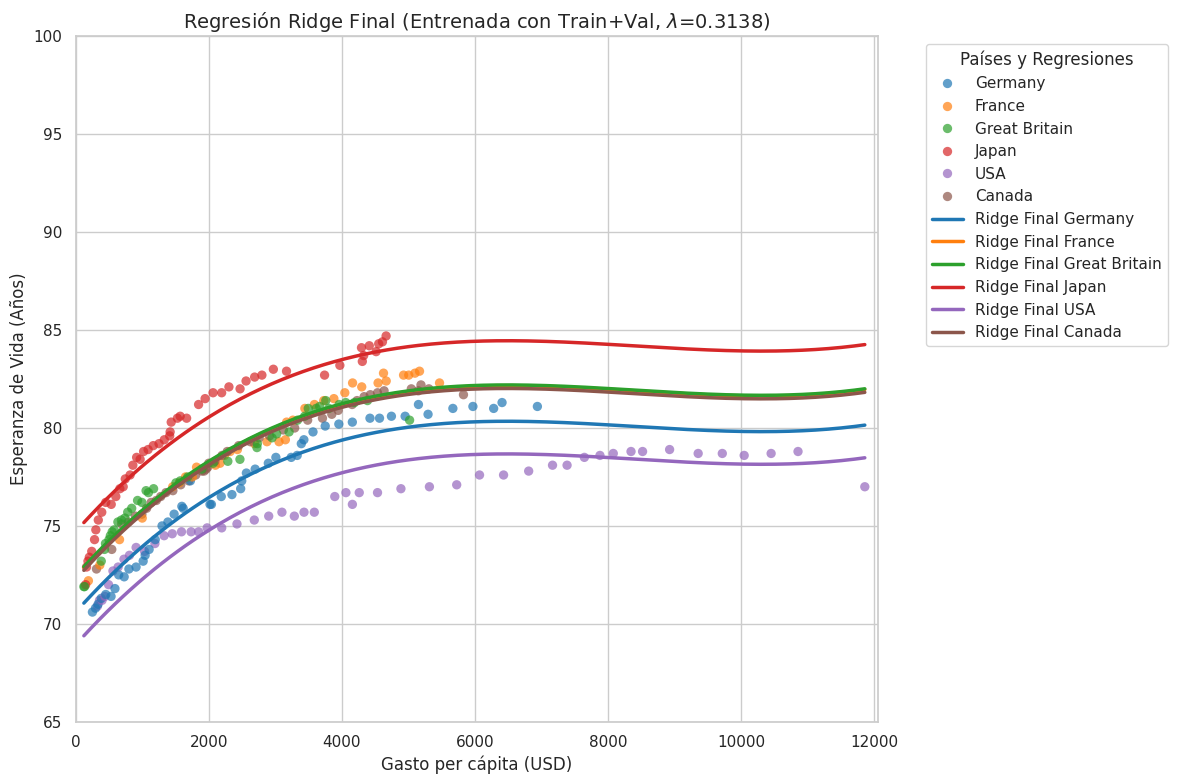

Resultado del Re-entrenamiento (Lambda = 0.3138).
MSE de Testeo Final: 0.4510


In [16]:
# Se combinan entrenamiento y validación
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Se crea el modelo final con el lambda óptimo
# Nota: Se crean NUEVAS instancias de los transformadores para evitar reutilizar instancias ya fitteadas
preprocessor_final = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['Country']),
        ('poly', PolynomialFeatures(degree=3, include_bias=False), ['Spending_USD'])
    ]
)

final_ridge_bis = Pipeline([
    ('prep', preprocessor_final),
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=best_lambda))
])

# Se re-entrena el modelo con los datos combinados
final_ridge_bis.fit(X_train_val, y_train_val)

# Se evalúa el modelo en el conjunto de testeo
y_test_pred = final_ridge_bis.predict(X_test)
mse_test_bis = mean_squared_error(y_test, y_test_pred)


# Se configura el estilo y paleta de colores
sns.set_theme(style="whitegrid")
paises = df['Country'].unique()
palette = sns.color_palette("tab10", n_colors=len(paises))

plt.figure(figsize=(12, 8))

# Se grafican los datos reales
sns.scatterplot(
    data=df,
    x='Spending_USD',
    y='Life_Expectancy',
    hue='Country',
    palette=palette,
    s=45,
    alpha=0.7,
    edgecolor='none'
)

# Se generan las curvas del modelo re-entrenado
gasto_max = df['Spending_USD'].max()
gasto_range = np.linspace(df['Spending_USD'].min(), gasto_max, 300)

for i, pais in enumerate(paises):
    X_plot = pd.DataFrame({'Country': [pais] * 300, 'Spending_USD': gasto_range})
    y_plot = final_ridge_bis.predict(X_plot)

    plt.plot(
        gasto_range,
        y_plot,
        color=palette[i],
        linewidth=2.5,
        label=f'Ridge Final {pais}'
    )

# Se ajusta la visualización
plt.ylim(65, 100)
plt.xlim(0, gasto_max + 200)

plt.title(r'Regresión Ridge Final (Entrenada con Train+Val, $\lambda$=' + f'{best_lambda:.4f})', fontsize=14)
plt.xlabel('Gasto per cápita (USD)', fontsize=12)
plt.ylabel('Esperanza de Vida (Años)', fontsize=12)
plt.legend(title='Países y Regresiones', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print(f"Resultado del Re-entrenamiento (Lambda = {best_lambda:.4f}).")
print(f"MSE de Testeo Final: {mse_test_bis:.4f}")

En este caso, una vez elegido el valor óptimo de $\lambda$, se volvió a entrenar el modelo utilizando en conjunto los datos de entrenamiento y validación, dejando el conjunto de testeo exclusivamente para la evaluación final.

El resultado obtenido fue:

$$
MSE_{test}^{final} = 0.4510
$$

Este valor representa una mejora muy marcada respecto del esquema anterior. A diferencia de lo que ocurría cuando el modelo se entrenaba solo con datos previos a 2008, ahora el reentrenamiento incorpora también la información del conjunto de validación, que ya contiene parte del cambio de comportamiento observado en los años más recientes.

Esto resulta especialmente importante en este problema, ya que del análisis exploratorio se había visto que, a partir de 2008, la relación entre gasto público en salud y esperanza de vida comienza a modificarse y las trayectorias de varios países tienden a aplanarse. Por lo tanto, incluir esos datos en el reentrenamiento permite que el modelo aprenda una representación más fiel de la dinámica que luego aparece en testeo.

Además, el gráfico de las curvas ajustadas confirma esta mejora: las predicciones resultan mucho más razonables, las curvas dejan de crecer de manera exagerada para valores altos de gasto y el ajuste general acompaña mejor la nube de puntos observada.

En síntesis, este resultado muestra que la mejora del modelo no dependía únicamente de regularizar los coeficientes, sino también de entrenar con datos más representativos del régimen temporal que se quería predecir. En este caso, el reentrenamiento con entrenamiento y validación produjo una mejora sustancial tanto en términos visuales como en el error final de testeo.

## Ítem E

En este apartado se pasa a la parte teórica del problema. La idea es justificar matemáticamente el modelo regularizado utilizado en el ítem anterior. Se estudiará cómo funciona Ridge. La idea es escribir la fórmula que el modelo minimiza, derivarla y, a partir de eso, obtener una expresión para los parámetros del modelo.

### Punto 1

En este punto se quiere escribir, de forma matemática, qué es lo que el modelo Ridge está tratando de minimizar cuando se entrena.

Se parte de un modelo lineal con sesgo, dado por:

$$
\hat y_i = w^T x_i + b
$$

Donde:

- $x_i$ es el vector de entrada asociado al dato $i$.
- $w$ es el vector de coeficientes del modelo.
- $b$ es el sesgo o término independiente.
- $\hat y_i$ es la predicción del modelo.

La idea es simple: el modelo toma un dato de entrada $x_i$ y, usando los parámetros $w$ y $b$, genera una predicción.


Para entrenar el modelo, se define una función de costo.  
Esa función mide dos cosas al mismo tiempo:

1. Qué tan lejos quedan las predicciones respecto de los valores reales.
2. Qué tan grandes son los coeficientes del modelo.

En Ridge, esto se escribe como:

$$
J(w,b)=\frac{1}{n_{tr}}\sum_{i=1}^{n_{tr}}(w^T x_i+b-y_i)^2+\frac{\lambda}{n_{tr}}\|w\|^2
$$

Esta expresión tiene dos partes:

- El primer término mide el error cuadrático medio sobre los datos de entrenamiento.
- El segundo término es la regularización Ridge, que penaliza coeficientes demasiado grandes.

Es importante notar que la regularización actúa sobre $w$, pero no sobre $b$.  
Es decir, el sesgo forma parte del modelo, pero no forma parte del término de penalización.

Ahora bien, para encontrar los parámetros óptimos, se deriva esta función de costo respecto de las variables que se quieren ajustar.

Derivando respecto de $w$, se obtiene:

$$
\nabla_w J(w,b)=\frac{2}{n_{tr}}X^T(Xw+b \cdot \mathbf{1}-y)+\frac{2\lambda}{n_{tr}}w
$$

Esta expresión muestra que, al derivar respecto de $w$, aparecen dos aportes:

- Uno proveniente del error de predicción.
- Otro proveniente de la regularización.

Por otro lado, derivando respecto del sesgo $b$, se obtiene:

$$
\frac{\partial J}{\partial b}=\frac{2}{n_{tr}}\mathbf{1}^T(Xw+b ⋅ \mathbf{1}-y)
$$

En este caso no aparece el término de regularización, porque el sesgo no está siendo penalizado.

Aunque el sesgo $b$ no se regulariza, sí forma parte del modelo y por lo tanto también debe ajustarse. Por eso se deriva la función de costo tanto respecto de $w$ como respecto de $b$. La diferencia es que la penalización Ridge solo afecta a $w$, ya que el término de regularización no incluye al sesgo.

En resumen, el gradiente del riesgo empírico regularizado queda dado por las derivadas anteriores. Esto permite ver con claridad que la regularización Ridge modifica la ecuación asociada a los coeficientes $w$, pero no modifica la ecuación asociada al sesgo $b$.

### Punto 2

En este punto se busca encontrar una expresión matricial para los parámetros óptimos del modelo Ridge. La idea es tomar las derivadas obtenidas en el punto anterior e imponer que valgan cero, ya que en el mínimo de la función de costo el gradiente debe anularse.

Partimos de la función de costo:

$$
J(w,b)=\frac{1}{n_{tr}}\|Xw+b\mathbf{1}-y\|^2+\frac{\lambda}{n_{tr}}\|w\|^2
$$

donde:

- $X \in \mathbb{R}^{n_{tr}\times d}$ es la matriz de datos,
- $w \in \mathbb{R}^d$ es el vector de coeficientes,
- $b \in \mathbb{R}$ es el sesgo,
- $y \in \mathbb{R}^{n_{tr}}$ es el vector de salidas reales,
- $\mathbf{1} \in \mathbb{R}^{n_{tr}}$ es el vector columna de unos.

Del punto E.1 se tenía:

$$
\nabla_w J(w,b)=\frac{2}{n_{tr}}X^T(Xw+b\mathbf{1}-y)+\frac{2\lambda}{n_{tr}}w
$$

Y:

$$
\frac{\partial J}{\partial b}=\frac{2}{n_{tr}}\mathbf{1}^T(Xw+b\mathbf{1}-y)
$$

Para encontrar el mínimo, se igualan ambas expresiones a cero.

---

#### 1. Ecuación asociada a $w$

Igualando a cero la derivada respecto de $w$:

$$
\frac{2}{n_{tr}}X^T(Xw+b\mathbf{1}-y)+\frac{2\lambda}{n_{tr}}w = 0
$$

Multiplicando por $\frac{n_{tr}}{2}$:

$$
X^T(Xw+b\mathbf{1}-y)+\lambda w = 0
$$

Reordenando:

$$
X^TX\,w + bX^T\mathbf{1} - X^Ty + \lambda w = 0
$$

Agrupando los términos en $w$:

$$
(X^TX+\lambda I)w + bX^T\mathbf{1} = X^Ty
$$

Esta es la primera ecuación del sistema.

---

#### 2. Ecuación asociada a $b$

Igualando a cero la derivada respecto del sesgo:

$$
\frac{2}{n_{tr}}\mathbf{1}^T(Xw+b\mathbf{1}-y)=0
$$

Multiplicando por $\frac{n_{tr}}{2}$:

$$
\mathbf{1}^T(Xw+b\mathbf{1}-y)=0
$$

Distribuyendo:

$$
\mathbf{1}^TXw + b\,\mathbf{1}^T\mathbf{1} - \mathbf{1}^Ty = 0
$$

Como $\mathbf{1}^T\mathbf{1}=n_{tr}$, queda:

$$
\mathbf{1}^TXw + bn_{tr} - \mathbf{1}^Ty = 0
$$

Despejando $b$:

$$
b=\frac{\mathbf{1}^Ty-\mathbf{1}^TXw}{n_{tr}}
$$

Esta expresión puede escribirse de forma más intuitiva usando medias. Si definimos

$$
\bar y = \frac{1}{n_{tr}}\mathbf{1}^Ty
\qquad\text{y}\qquad
\bar x = \frac{1}{n_{tr}}X^T\mathbf{1}
$$

Entonces:

$$
b = \bar y - \bar x^T w
$$

Es decir, una vez conocido $w$, el sesgo se obtiene restando al promedio de las salidas el promedio de las entradas ponderado por $w$.

---

#### 3. Reemplazo de $b$ en la ecuación de $w$

Ahora se reemplaza la expresión de $b$ en la ecuación anterior. Para hacerlo de forma ordenada, conviene centrar los datos.

Definimos:

$$
X_c = X - \mathbf{1}\bar x^T
$$

Y

$$
y_c = y - \bar y ⋅ \,\mathbf{1}
$$

donde $X_c$ y $y_c$ representan la matriz de datos y el vector de salidas centrados.

Con estas definiciones, la ecuación para $w$ se simplifica a:

$$
(X_c^TX_c+\lambda I)w = X_c^Ty_c
$$

Finalmente, despejando:

$$
w^\star = (X_c^TX_c+\lambda I)^{-1}X_c^Ty_c
$$

y luego el sesgo queda dado por:

$$
b^\star = \bar y - \bar x^T w^\star
$$

---

### Resultado final

Por lo tanto, la solución matricial del problema Ridge, cuando el sesgo forma parte del modelo pero no se regulariza, queda dada por:

$$
w^\star = (X_c^TX_c+\lambda I)^{-1}X_c^Ty_c
$$

$$
b^\star = \bar y - \bar x^T w^\star
$$

---

### Interpretación

Este resultado muestra que la regularización Ridge modifica únicamente la ecuación asociada a los coeficientes $w$, agregando el término $\lambda I$. En cambio, el sesgo $b$ no recibe penalización y se calcula aparte a partir de los promedios de los datos.

En otras palabras:

- $w$ se obtiene resolviendo un sistema lineal regularizado;
- $b$ se ajusta después, de manera de compensar el nivel medio de los datos.

Esto es consistente con la idea planteada en el enunciado: el sesgo se incluye en el modelo, pero no en el término de regularización.